In [119]:
import pandas as pd
import polars as pl
import seaborn as sns
import numpy as np
from datacommons_client.client import DataCommonsClient

In [2]:
client = DataCommonsClient(dc_instance="datacommons.one.org")

Notes:

- We will likely have underrepresentation of WDBs that are in areas with smaller populations since the WIOA data does not report the WBD code when their are less than 50 participants.


In [93]:
dict_workforce_boards = {}
dict_workforce_boards[2023] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2023.xlsx", skiprows=8)
dict_workforce_boards[2022] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2022.xlsx", skiprows=8)
dict_workforce_boards[2021] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2021.xlsx", skiprows=8)
dict_workforce_boards[2020] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2020.xlsx", skiprows=8)
dict_workforce_boards[2019] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2019.xlsx", skiprows=8)
dict_workforce_boards[2018] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2018.xlsx", skiprows=8)
dict_workforce_boards[2017] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2017.xlsx", skiprows=8)
dict_workforce_boards[2016] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2016.xlsx", skiprows=8)

In [ ]:
# For Program Years 2015 an earlier, the format of the Workforce Board Reporting Codes differs. In particular,
# PY2012 - PY2014, do not have a Jurisdiction Name and therefore are not included in this analysis.

df_wdb2015 = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2015.xlsx", skiprows=1)

# We remove unnecessary header rows which include state name and "ETA Assigned Code"
indices_to_remove = df_wdb2015[df_wdb2015["ETA Assigned Code"] == "ETA Assigned Code"].index
indices_to_remove = indices_to_remove.append(indices_to_remove - 1)
df_wdb2015 = df_wdb2015.drop(indices_to_remove).reset_index(drop=True)

# Rename columns to match earlier program years
df_wdb2015 = df_wdb2015.rename(columns={
    "ETA Assigned Code": "ETA Code",
    "Local Board Name": "Local Board Name",
    "Local Jurisdiction Name": "Jurisdiction Name"
})

df_wdb2015["ETA Code"] = df_wdb2015["ETA Code"].astype(int)

df_wdb2015["Program Year"] = 2015

dict_workforce_boards[2015] = df_wdb2015

In [148]:
df_workforce_boards = pd.concat(dict_workforce_boards.values())

# Remove entries that are deactivated or pending deactivation
is_status_active = df_workforce_boards["Status"].isin(["Approved", "Edit-Pending Approval"])

df_workforce_boards = df_workforce_boards[is_status_active].copy()

df_workforce_boards = df_workforce_boards.rename(columns={
    "Program Year": "program_year",
    "Region": "region",
    "State/Territory": "state",
    "ETA Code": "workforce_board_code",
    "Local Board Name": "local_board",
    "Jurisdiction Name": "jurisdiction"
}).drop(columns=["Created Timestamp", "Modified Timestamp", "Status"])

In [154]:
# Determine if the jurisdiction of workforce boards is changing between program years

df_workforce_boards = df_workforce_boards.sort_values(by=["jurisdiction"], ascending=True)

df_workforce_boards_grouped = df_workforce_boards.groupby(by=["program_year", "state", "workforce_board_code"])["jurisdiction"].apply(tuple).reset_index()

df_workforce_boards_grouped = df_workforce_boards_grouped.sort_values(by=["program_year", "state"], ascending=False)

# Remove duplicates that repeat across program years if they cover the same jurisdiction
df_workforce_boards_grouped = df_workforce_boards_grouped[~df_workforce_boards_grouped.duplicated(subset=["workforce_board_code", "state", "jurisdiction"])].reset_index(drop=True)

In [162]:
df_workforce_boards_grouped

,program_year,state,workforce_board_code,jurisdiction
0,2023,Wyoming,56005,"(Albany County, Big Horn County, Campbell Coun..."
1,2023,Wisconsin,55015,"(Milwaukee County,)"
2,2023,Wisconsin,55030,"(Kenosha County, Racine County, Walworth County)"
3,2023,Wisconsin,55040,"(Ashland County, Bayfield County, Burnett Coun..."
4,2023,Wisconsin,55045,"(Ozaukee County, Washington County, Waukesha C..."
...,...,...,...,...
621,2016,California,6230,"(Napa County,)"
622,2016,California,6235,"(Mendocino County,)"
623,2016,Alabama,1005,"(Jefferson County,)"
624,2016,Alabama,1010,"(Mobile City/Mobile County,)"


In [156]:
df_workforce_boards_grouped["program_year"].value_counts()

program_year
2023    576
2022     24
2017     13
2016     10
2019      2
2020      1
Name: count, dtype: int64

In [113]:
is_state = df_workforce_boards["state"] == "Ohio"
is_jurisdiction = df_workforce_boards["jurisdiction"] == "Medina County"

df_workforce_boards[is_state & is_jurisdiction]

,program_year,region,state,workforce_board_code,local_board,jurisdiction
2838,2023,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2859,2022,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2857,2021,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2858,2020,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2789,2019,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2789,2018,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2789,2017,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County
2789,2016,Region 5,Ohio,39255,"WIA Area 2, Medina & Summit",Medina County


In [ ]:
df_workforce_boards.pivot_table(values="")

In [ ]:
for year, df in df_workforce_boards.items():
    print(year, df.dtypes)

<Axes: xlabel='Jurisdiction Name', ylabel='Count'>

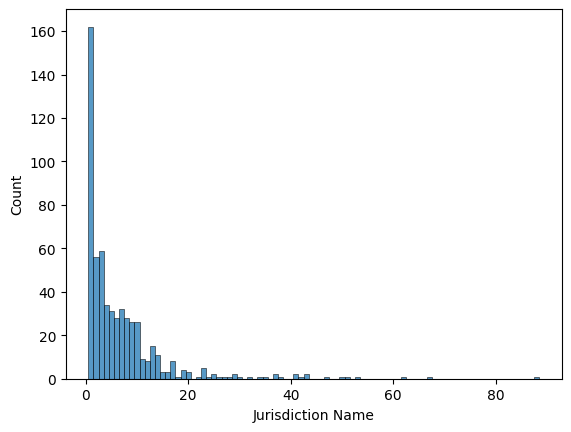

In [76]:
sns.histplot(df_workforce_boards[2023].groupby(by=["ETA Code"])["Jurisdiction Name"].nunique(), discrete=True)

In [67]:
df_workforce_boards[2015]

,ETA Code,Local Board Name,Jurisdiction Name
0,01015,Alabama Workforce Development Division,AUTAUGA COUNTY
1,01015,Alabama Workforce Development Division,BALDWIN COUNTY
2,01015,Alabama Workforce Development Division,BARBOUR COUNTY
3,01015,Alabama Workforce Development Division,BIBB COUNTY
4,01015,Alabama Workforce Development Division,BLOUNT COUNTY
...,...,...,...
3944,72090,ALDL Suroeste,SAN GERMAN MUNICIPIO
3945,72090,ALDL Suroeste,YAUCO MUNICIPIO
3946,78005,Virgin Islands Sda,ST. CROIX ISLAND
3947,78005,Virgin Islands Sda,ST. JOHN ISLAND


In [61]:
for year, df in df_workforce_boards.items():
    print(year, df.dtypes)

2023 Program Year           int64
Region                object
State/Territory       object
ETA Code               int64
Local Board Name      object
Jurisdiction Name     object
Created Timestamp     object
Modified Timestamp    object
Status                object
dtype: object
2022 Program Year          int64
Region               object
State/Territory      object
ETA Code              int64
Local Board Name     object
Jurisdiction Name    object
Created Timestamp    object
Status               object
dtype: object
2021 Program Year          int64
Region               object
State/Territory      object
ETA Code              int64
Local Board Name     object
Jurisdiction Name    object
Created Timestamp    object
Status               object
dtype: object
2020 Program Year          int64
Region               object
State/Territory      object
ETA Code              int64
Local Board Name     object
Jurisdiction Name    object
Created Timestamp    object
Status               object
dtype

In [53]:
df_workforce_boards[2023]

,Program Year,Region,State/Territory,ETA Code,Local Board Name,Jurisdiction Name,Created Timestamp,Modified Timestamp,Status
0,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Shelby County,01-Jun-2023,NaN,Approved
1,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Jefferson County,01-Jun-2023,NaN,Approved
2,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Walker County,01-Jun-2023,NaN,Approved
3,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Chilton County,01-Jun-2023,NaN,Approved
4,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,St. Clair County,01-Jun-2023,NaN,Approved
...,...,...,...,...,...,...,...,...,...
3995,2023,Region 1,Puerto Rico,72155,ALDL Surcentral,Santa Isabel Municipio,01-Jun-2023,NaN,Approved
3996,2023,Region 1,Puerto Rico,72155,ALDL Surcentral,Salinas Municipio,01-Jun-2023,NaN,Approved
3997,2023,Region 1,Virgin Islands,78005,Virgin Islands Sda,St. Thomas Island,01-Jun-2023,NaN,Approved
3998,2023,Region 1,Virgin Islands,78005,Virgin Islands Sda,St. John Island,01-Jun-2023,NaN,Approved


In [16]:
lf = pl.scan_parquet("../data/processed/wioa_data_filtered.parquet")

In [20]:
df = (
    lf.select(
        pl.col("workforce_board_code_1").unique()
    )
    .collect()
)

In [23]:
df = df.to_pandas()

In [26]:
df_workforce_boards = df_workforce_boards.rename(
    columns={
        "Program Year": "program_year",
        "Region": "region",
        "State/Territory": "state",
        "ETA Code": "eta_code",
        "Local Board Name": "local_board_name",
        "Jurisdiction Name": "jurisdiction_name",
        "Created Timestamp": "created_timestamp",
        "Modified Timestamp": "modified_timestamp",
        "Status": "status"
    }
)

In [31]:
df_workforce_boards["eta_code"] = df_workforce_boards["eta_code"].astype(str)

In [34]:
df

,workforce_board_code_1
0,36230
1,34010
2,48245
3,42005
4,29085
...,...
345,37215
346,48235
347,37225
348,34030


In [49]:
eta_codes = set(df_workforce_boards["eta_code"].unique())
workforce_board_codes = set(df["workforce_board_code_1"].unique())

In [54]:
len(workforce_board_codes)

350

In [53]:
len(workforce_board_codes - eta_codes)

32

In [35]:
df.merge(df_workforce_boards, left_on="workforce_board_code_1", right_on="eta_code", how="inner")

,workforce_board_code_1,program_year,region,state,eta_code,local_board_name,jurisdiction_name,created_timestamp,modified_timestamp,status
0,36230,2023,Region 1,New York,36230,Dutchess County,Dutchess County,01-Jun-2023,NaN,Approved
1,34010,2023,Region 1,New Jersey,34010,Union County Workforce Investment Board,Union County,01-Jun-2023,NaN,Approved
2,48245,2023,Region 4,Texas,48245,South Plains Workforce Development Board,Floyd County,01-Jun-2023,NaN,Approved
3,48245,2023,Region 4,Texas,48245,South Plains Workforce Development Board,Lynn County,01-Jun-2023,NaN,Approved
4,48245,2023,Region 4,Texas,48245,South Plains Workforce Development Board,Bailey County,01-Jun-2023,NaN,Approved
...,...,...,...,...,...,...,...,...,...,...
1892,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Polk County,01-Jun-2023,NaN,Approved
1893,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Dunn County,01-Jun-2023,NaN,Approved
1894,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Pierce County,01-Jun-2023,NaN,Approved
1895,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Clark County,01-Jun-2023,NaN,Approved


In [5]:
df['jurisdiction_state'] = df.apply(lambda x : x["jurisdiction_name"] + ', ' + x["state"] , axis=1)

In [6]:
county_names = df['jurisdiction_state'].unique()

In [9]:
df

,program_year,region,state,eta_code,local_board_name,jurisdiction_name,created_timestamp,modified_timestamp,status,jurisdiction_state
0,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Shelby County,01-Jun-2023,NaN,Approved,"Shelby County, Alabama"
1,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Jefferson County,01-Jun-2023,NaN,Approved,"Jefferson County, Alabama"
2,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Walker County,01-Jun-2023,NaN,Approved,"Walker County, Alabama"
3,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,Chilton County,01-Jun-2023,NaN,Approved,"Chilton County, Alabama"
4,2023,Region 3,Alabama,1020,Central Alabama Partnership for Training and E...,St. Clair County,01-Jun-2023,NaN,Approved,"St. Clair County, Alabama"
...,...,...,...,...,...,...,...,...,...,...
3995,2023,Region 1,Puerto Rico,72155,ALDL Surcentral,Santa Isabel Municipio,01-Jun-2023,NaN,Approved,"Santa Isabel Municipio, Puerto Rico"
3996,2023,Region 1,Puerto Rico,72155,ALDL Surcentral,Salinas Municipio,01-Jun-2023,NaN,Approved,"Salinas Municipio, Puerto Rico"
3997,2023,Region 1,Virgin Islands,78005,Virgin Islands Sda,St. Thomas Island,01-Jun-2023,NaN,Approved,"St. Thomas Island, Virgin Islands"
3998,2023,Region 1,Virgin Islands,78005,Virgin Islands Sda,St. John Island,01-Jun-2023,NaN,Approved,"St. John Island, Virgin Islands"


In [ ]:
# Fetch the corresponding DCIDs for the juristictions
counties = client.resolve.fetch_dcids_by_name(county_names).to_flat_dict()

In [35]:
# Extract just the DCIDs
county_dcids = [counties[county_name] for county_name in county_names if isinstance(counties[county_name], str)]

In [39]:
len(county_dcids)

3872

In [36]:
df_county = client.observations_dataframe(entity_dcids=county_dcids, variable_dcids=['Count_Person', 'Median_Age_Person', 'Median_Income_Person'], date='latest')

In [37]:
df_county

,date,entity,entity_name,variable,variable_name,facetId,importName,measurementMethod,observationPeriod,provenanceUrl,unit,value
0,2024,geoId/28095,Monroe County,Count_Person,Total population,2176550201,USCensusPEP_Annual_Population,CensusPEPSurvey,P1Y,https://www.census.gov/programs-surveys/popest...,None,33483.0
1,2023,geoId/28095,Monroe County,Count_Person,Total population,1145703171,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,None,33928.0
2,2020,geoId/28095,Monroe County,Count_Person,Total population,1541763368,USDecennialCensus_RedistrictingRelease,USDecennialCensus,None,https://www.census.gov/programs-surveys/decenn...,None,34180.0
3,2024,geoId/28095,Monroe County,Count_Person,Total population,2390551605,USCensusPEP_AgeSexRaceHispanicOrigin,CensusPEPSurvey_Race2000Onwards,P1Y,https://www2.census.gov/programs-surveys/popes...,None,33483.0
4,2023,geoId/28095,Monroe County,Count_Person,Total population,1964317807,CensusACS5YearSurvey_SubjectTables_S0101,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/table?q=S0101:+Age+and...,None,33928.0
...,...,...,...,...,...,...,...,...,...,...,...,...
42719,2023,geoId/48065,Carson County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,42308.0
42720,2023,geoId/53057,Skagit County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,42170.0
42721,2023,geoId/53057,Skagit County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,42170.0
42722,2023,geoId/13121,Fulton County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,50463.0


In [24]:
df_county[df_county["variable"] == "Median_Income_Person"]

,date,entity,entity_name,variable,variable_name,facetId,importName,measurementMethod,observationPeriod,provenanceUrl,unit,value
64,2023,geoId/01117,Shelby County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,46566.0
65,2023,geoId/01117,Shelby County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,46566.0
66,2023,geoId/01073,Jefferson County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,35600.0
67,2023,geoId/01073,Jefferson County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,35600.0
68,2023,geoId/01127,Walker County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,29524.0
69,2023,geoId/01127,Walker County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,29524.0
70,2023,geoId/01021,Chilton County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,31816.0
71,2023,geoId/01021,Chilton County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,31816.0
72,2023,geoId/01115,St. Clair County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,37446.0
73,2023,geoId/01115,St. Clair County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,37446.0


In [ ]:
df.to_csv("data/processed/workforce_boards.csv")